# A short analysis of the vaccinations per country and the vaccines used. COVID-19 World Vaccination Progress Dataset


### Raúl Almuzara

-------------------------------------

This notebook is also available in my Kaggle profile: https://www.kaggle.com/code/raulalmuzara/covid-19-ranking-of-vaccinations-and-vaccines-used

--------------------------------

Using the dataset

https://www.kaggle.com/gpreda/covid-world-vaccination-progress

Find:

a. The ranking of countries based on the number of vaccinated people (attribute $people\_fully\_vaccinated$).

b. The list with the vaccines used.

c. At least two other types of info which can be extracted from the dataset.

----------------------------------------

#### Import libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Load datasets:

Two datasets are provided.

In [2]:
# Both files can be downloaded in the Kaggle link above (version 248). They are also in this GitHub repository.
# They must be placed in the same folder as this notebook if no path is specified.
data1 = pd.read_csv('country-vaccinations-v248.csv',sep=',')
data2 = pd.read_csv('country-vaccinations-by-manufacturer-v248.csv',sep=',')

#### Note that the dataset is updated very often with new data every few days. I carried out the following analysis on March 14, 2022 with the latest data available at that time. That is, version 248 uploaded on March 8, 2022.

-----------------------------------

# Task a. The ranking of countries based on the number of vaccinated people (attribute $people\_fully\_vaccinated$)

We have data for different days and the numbers in the attribute $people\_fully\_vaccinated$ are cumulative.

In total, the dataset has 223 countries:

In [3]:
len(np.unique(data1['country']))

223

We will need to retrieve the value for the latest date where there is available data (when we do not have the NaN value) for each country.

Since NaN values in the attribute $people\_fully\_vaccinated$ do not provide information, we drop them.

In [4]:
clean_data1 = data1.dropna(subset=['people_fully_vaccinated'])

which leaves 222 countries with numerical values for $people\_fully\_vaccinated$

In [5]:
len(np.unique(clean_data1['country']))

222

Unfortunately, we do not have information for the number of people fully vaccinated in Ethiopia since it is the only country where there is a NaN value in all its days.

In [6]:
data1[data1['country']=='Ethiopia']['people_fully_vaccinated'].isna().all()

True

Therefore, we will not include it in the ranking, since its actual values are unknown because they have not been provided. The remaining countries that have not been dropped are those that have at least one numerical value at some date. Maybe, that date is not always the latest possible, but we will consider them as a good approximation of the state of vaccination in a country.

We define the following two arrays to store the countries and the desired values of the attribute.

In [7]:
list_countries = np.unique(clean_data1['country']) # Full list of countries in the dataset

latest_vaccinations = np.array([]) # Here, we will save the latest values for 'people_fully_vaccinated'

Iterate over each country.

In [8]:
for country in list_countries:
    latest_vaccinations = np.append(latest_vaccinations,
                                    clean_data1[clean_data1['country']==country] # Append the data for each country
                                    .iloc[-1]['people_fully_vaccinated'])
                                    # We find the latest data in the index -1 (last instance of each country)

Thus, we end up with a dataframe where each country can be associated with the desired value:

In [9]:
fully_vaccinated = pd.DataFrame({'country': list_countries,
                                'people_fully_vaccinated': latest_vaccinations})

Finally, we sort the data to create a ranking

In [10]:
ranking1 = fully_vaccinated.sort_values(by=['people_fully_vaccinated'],ascending=False,ignore_index=True)

In [11]:
ranking1

,country,people_fully_vaccinated
0,China,1.234540e+09
1,India,8.023584e+08
2,United States,2.153981e+08
3,Brazil,1.559305e+08
4,Indonesia,1.480214e+08
...,...,...
217,Falkland Islands,1.775000e+03
218,Montserrat,1.749000e+03
219,Niue,1.288000e+03
220,Tokelau,9.680000e+02


So, this is the final result according to the available data without taking into account those countries for which all values in the attribute $people\_fully\_vaccinated$ were NaN (just Ethiopia).

The countries with the highest number of fully vaccinated people are China, India, the United States, Brazil and Indonesia. They also happen to be among the most populated countries in the world, so it makes sense.

On the contrary, the countries with the lowest number of fully vaccinated people are the Falkland Islands, Montserrat, Niue, Tokelau and Pitcairn. They are regions with an extremely low number of inhabitants.

--------------------------------------

# Task b. The list with the vaccines used

This information is available in the first dataset in the attribute $vaccines$. We can access this information for each country. For example, in Afghanistan:

In [12]:
np.unique(data1[data1['country']=='Afghanistan']['vaccines'])

array(['Johnson&Johnson, Oxford/AstraZeneca, Pfizer/BioNTech, Sinopharm/Beijing'],
      dtype=object)

However, the full list of vaccines is more easily accesible in the SECOND dataset in the attribute $vaccine$, where each type of vaccine has its own row, so we can make a full list with each vaccine extracted individually.

In [13]:
np.unique(data2['vaccine'])

array(['CanSino', 'Covaxin', 'Johnson&Johnson', 'Moderna', 'Novavax',
       'Oxford/AstraZeneca', 'Pfizer/BioNTech', 'Sinopharm/Beijing',
       'Sinovac', 'Sputnik V'], dtype=object)

--------------------------------------------

# Task c. At least two of other types of info which can be extracted from the dataset

We can observe the full list of attributes in the first dataset.

In [14]:
data1.columns

Index(['country', 'iso_code', 'date', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated',
       'daily_vaccinations_raw', 'daily_vaccinations',
       'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
       'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million',
       'vaccines', 'source_name', 'source_website'],
      dtype='object')

And in the second dataset.

In [15]:
data2.columns

Index(['location', 'date', 'vaccine', 'total_vaccinations'], dtype='object')

For example, we may look at the total number of people fully vaccinated per hundred. This is the ratio (in percent) between population fully immunized and total population up to the date in the country. It could be interesting to study ratios instead of absolute numbers as in Task a. The absolute numbers that were described in Task a. strongly depend on how populated a country is. Obviously, if a country has many inhabitants, there is a higher chance that the country will have more vaccinated people than countries with few inhabitants, so the ranking is led by highly populated countries. The ratio in the attribute $people\_fully\_vaccinated\_per\_hundred$ may solve this bias.

Proceeding as in Task a., we will obtain a new ranking based on this new attribute.

In [16]:
clean_data1_h = data1.dropna(subset=['people_fully_vaccinated_per_hundred'])

latest_ratio = np.array([]) # Here, we will save the latest values for 'people_fully_vaccinated_per_hundred'

for country in list_countries:
    latest_ratio = np.append(latest_ratio,
                            clean_data1_h[clean_data1_h['country']==country]
                            .iloc[-1]['people_fully_vaccinated_per_hundred'])

ratio_fully_vaccinated = pd.DataFrame({'country': list_countries,
                                'people_fully_vaccinated_per_hundred': latest_ratio})

ranking2 = ratio_fully_vaccinated.sort_values(by=['people_fully_vaccinated_per_hundred'],ascending=False,ignore_index=True)

In [17]:
ranking2

,country,people_fully_vaccinated_per_hundred
0,Gibraltar,121.53
1,Pitcairn,100.00
2,United Arab Emirates,95.33
3,Portugal,92.57
4,Brunei,91.61
...,...,...
217,Yemen,1.26
218,Haiti,0.91
219,Chad,0.84
220,Democratic Republic of Congo,0.48


There seems to be a strange value because Gibraltar has a ratio higher than 100%. Gibraltar reached an extremely high ratio (very close to 100%), but it does not have a large population. That may have caused some kind of numerical error, or maybe some data have been preprocessed in an unexpected way.

Other countries with high vaccination ratios seem to be Pitcairn, the United Arab Emirates, Portugal and Brunei. None of them appeared in the top 5 of the ranking in Task a., so this gives a new perspective taking into account both the number of vaccinations and the population of the country.

On the contrary, we see that countries such as Yemen, Haiti, Chad, the Democratic Republic of Congo or Burundi seem to have the lowest vaccination ratios according to this dataset. They happen to be among the poorest countries in the world.

Finally, we can extract another piece of information from the second dataset. There, we saw in Task b. that there is a row for each type of vaccine in each day in each country. But also, in the attribute $total\_vaccinations$, we have the exact number of vaccines of each type in each day in each country. This could give us an idea of which vaccines were more widely used in the selection of 41 countries + the European Union as a whole that appear in this second dataset.

In [18]:
np.unique(data2['location'])

array(['Austria', 'Belgium', 'Bulgaria', 'Chile', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Ecuador', 'Estonia', 'European Union',
       'Finland', 'France', 'Germany', 'Hong Kong', 'Hungary', 'Iceland',
       'Ireland', 'Italy', 'Japan', 'Latvia', 'Liechtenstein',
       'Lithuania', 'Luxembourg', 'Malta', 'Nepal', 'Netherlands',
       'Norway', 'Peru', 'Poland', 'Portugal', 'Romania', 'Slovakia',
       'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden',
       'Switzerland', 'Ukraine', 'United States', 'Uruguay'], dtype=object)

Again, the data about the number of vaccines of each type are cumulative, so we will pay attention to the most recent value of each type.

For example, we could study the data in the European Union. The different types of COVID-19 vaccines administered in the European Union are the following:

In [19]:
types_EU = np.unique(data2[data2['location']=='European Union']['vaccine'])

In [20]:
types_EU

array(['Covaxin', 'Johnson&Johnson', 'Moderna', 'Novavax',
       'Oxford/AstraZeneca', 'Pfizer/BioNTech', 'Sinopharm/Beijing',
       'Sinovac', 'Sputnik V'], dtype=object)

So we keep the latest values in this dataset (from March 7, 2022).

In [21]:
cova = data2[(data2['location']=='European Union') & 
             (data2['date']=='2022-03-07') & 
             (data2['vaccine']=='Covaxin')]['total_vaccinations'].iloc[0]

jandj = data2[(data2['location']=='European Union') & 
              (data2['date']=='2022-03-07') & 
              (data2['vaccine']=='Johnson&Johnson')]['total_vaccinations'].iloc[0]

mod = data2[(data2['location']=='European Union') & 
              (data2['date']=='2022-03-07') & 
              (data2['vaccine']=='Moderna')]['total_vaccinations'].iloc[0]

nova = data2[(data2['location']=='European Union') & 
              (data2['date']=='2022-03-07') & 
              (data2['vaccine']=='Novavax')]['total_vaccinations'].iloc[0]

oxfast = data2[(data2['location']=='European Union') & 
              (data2['date']=='2022-03-07') & 
              (data2['vaccine']=='Oxford/AstraZeneca')]['total_vaccinations'].iloc[0]

pfibio = data2[(data2['location']=='European Union') & 
              (data2['date']=='2022-03-07') & 
              (data2['vaccine']=='Pfizer/BioNTech')]['total_vaccinations'].iloc[0]

sinobei = data2[(data2['location']=='European Union') & 
              (data2['date']=='2022-03-07') & 
              (data2['vaccine']=='Sinopharm/Beijing')]['total_vaccinations'].iloc[0]

sinov = data2[(data2['location']=='European Union') & 
              (data2['date']=='2022-03-07') & 
              (data2['vaccine']=='Sinovac')]['total_vaccinations'].iloc[0]

sput = data2[(data2['location']=='European Union') & 
              (data2['date']=='2022-03-07') & 
              (data2['vaccine']=='Sputnik V')]['total_vaccinations'].iloc[0]

numbers_EU = [cova,jandj,mod,nova,oxfast,pfibio,sinobei,sinov,sput]

In [22]:
for i in range(len(types_EU)):
    print(types_EU[i]+': '+str(numbers_EU[i]))

Covaxin: 9
Johnson&Johnson: 18529812
Moderna: 144294313
Novavax: 43363
Oxford/AstraZeneca: 67394646
Pfizer/BioNTech: 595924705
Sinopharm/Beijing: 2298001
Sinovac: 1262
Sputnik V: 1845103


A bar plot is helpful to understand the relative magnitude of each number with respect to the others.

Text(0.5, 1.0, 'COVID-19 vaccines administered in the European Union until March 7, 2022')

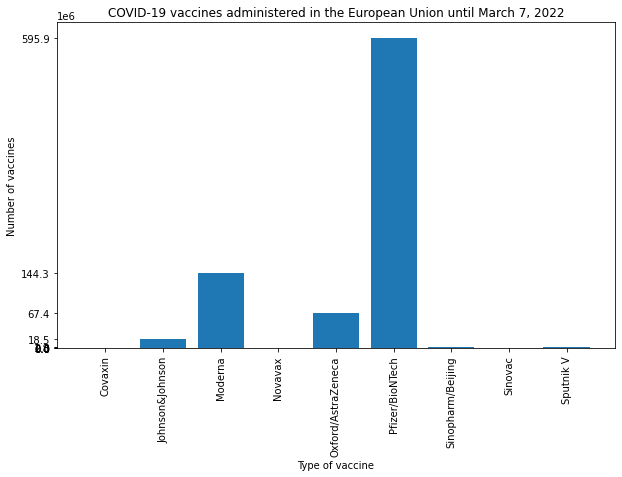

In [23]:
plt.figure(figsize=(10,6))
plt.bar(types_EU,numbers_EU)
plt.xticks(types_EU,rotation='vertical')
plt.yticks(numbers_EU)
plt.xlabel('Type of vaccine')
plt.ylabel('Number of vaccines')
plt.title('COVID-19 vaccines administered in the European Union until March 7, 2022')